In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1775146164.387164   17529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775146164.392885   17529 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775146165.018668   17529 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775146169.682646   17529 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

In [2]:
# Load in movie tower
movie_tower = tf.keras.models.load_model("movie_tower.keras")

# Load in movie data
movies = pd.read_csv("data/movies.csv")
unique_movie_ids = movies['movieId'].unique()

E0000 00:00:1775146173.353815   17529 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
movie_input = np.array(unique_movie_ids)
movie_embeddings = movie_tower.predict(movie_input)

305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step


In [4]:
tsne = TSNE(n_components=2, perplexity=20, random_state=42)
embeddings_2d = tsne.fit_transform(movie_embeddings)


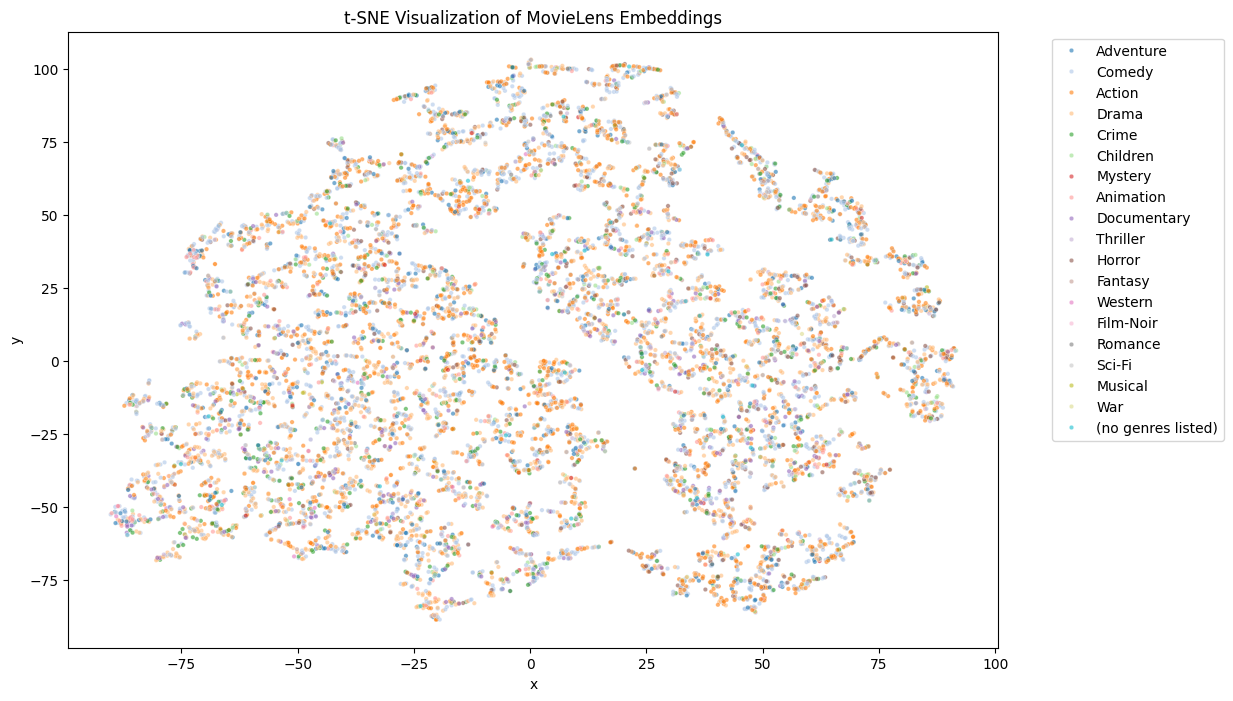

In [5]:
# Create a temporary dataframe for plotting
tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0] # Take the first genre listed
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=tsne_df, 
    x='x', y='y', 
    hue='genre', 
    palette='tab20',
 
    alpha=0.6, 
    s=10
)
plt.title('t-SNE Visualization of MovieLens Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [7]:
# Make sure movies_df and embeddings_2d have the same number of rows
# (This assumes movies_df is the same one used to generate movie_embeddings)

tsne_df = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'genre': movies['genres'].str.split('|').str[0],
    'title': movies['title'].values  # <--- Add this line!
})

# Now run the plotly code again
import plotly.express as px

fig = px.scatter(
    tsne_df, 
    x='x', 
    y='y', 
    color='genre', 
    hover_data=['title'],
    title="Interactive Movie Clusters"
)
fig.show()